In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = next(
    (path for path in [Path.cwd(), *Path.cwd().parents] if (path / "config.yaml").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find the project root containing config.yaml.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import PROJECT_ROOT, load_config

sns.set_theme(style="whitegrid", context="notebook")

config = load_config()
data_path = (PROJECT_ROOT / config["data"]["output_path"]).resolve()
if not data_path.is_file():
    raise FileNotFoundError(
        f"Processed data not found at {data_path}. Run `python main.py` from the project root first."
    )

df = pd.read_csv(data_path, sep=config["data"].get("delimiter", ";"))
print(f"Loaded processed data: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Loaded processed data: 15,450 rows x 31 columns


,member_id,age,gender,industry,country,is_team_account,n_colleagues_on_account,plan_tier,plan_days_per_week,membership_start,...,uses_event_space,uses_guest_passes,uses_print,uses_mail_handling,uses_phone_booths,uses_day_passes,uses_storage,uses_bike_locker,n_renewals,lifetime_value
0,CW000001,38.0,Female,Information Technology,Portugal,False,0.0,flex,3.0,2021-08-01,...,False,True,False,False,True,True,False,False,2.0,4477.97
1,CW000002,38.0,Male,Information Technology,Portugal,True,2.0,hot_desk,2.0,2023-11-24,...,False,False,False,True,False,False,False,False,0.0,165.86
2,CW000003,43.0,Male,Education,Germany,True,1.0,flex,3.0,2021-12-03,...,False,False,False,False,False,False,False,False,1.0,4486.17
3,CW000004,38.0,Female,Legal,Portugal,False,0.0,flex,3.0,2022-01-02,...,False,False,False,False,False,False,False,False,0.0,258.63
4,CW000005,45.0,Female,Information Technology,United Kingdom,False,0.0,hot_desk,2.0,2023-10-24,...,False,False,False,False,False,True,False,False,0.0,335.74


## Data quality: duplicates and missingness

This uses the preprocessed data. Missingness includes NAs created by preprocessing rules and normalized placeholder values.

Shape: 15,450 rows x 31 columns
Exact duplicate rows beyond first copies: 0
Rows belonging to exact-duplicate groups: 0


,n_missing,percent_missing
meeting_room_hours,1311,8.485437
guest_passes_issued,1276,8.258900
lifetime_value,1166,7.546926
age,700,4.530744
industry,693,4.485437
n_colleagues_on_account,565,3.656958
gender,530,3.430421
country,429,2.776699
plan_tier,105,0.679612
n_renewals,66,0.427184


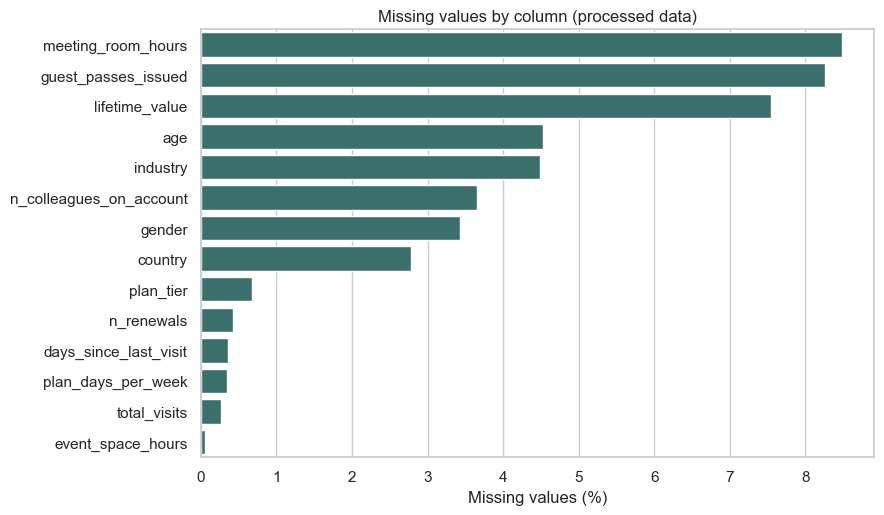

Violations by configured numeric rule:


,column,min_allowed,max_allowed,below_min,above_max,violations
0,age,18,100,98,45,143
1,n_colleagues_on_account,0,10,565,0,565
2,plan_days_per_week,0,7,0,54,54
3,days_since_last_visit,0,1300,56,0,56
4,total_visits,0,6600,42,0,42
5,avg_weekly_visits,0,100,0,0,0
6,entitled_visits_last_period,0,200,0,0,0
7,actual_visits_last_period,0,200,0,0,0
8,meeting_room_hours,0,50000,16,0,16
9,event_space_hours,0,605,8,0,8


Original invalid values and how often they occur:


,column,condition,original_value,min_allowed,max_allowed,n_rows
0,age,above_max,131.0,18,100,7
1,age,above_max,132.0,18,100,3
2,age,above_max,134.0,18,100,4
3,age,above_max,135.0,18,100,3
4,age,above_max,136.0,18,100,2
...,...,...,...,...,...,...
263,total_visits,below_min,-8.0,0,6600,1
264,total_visits,below_min,-6.0,0,6600,1
265,total_visits,below_min,-4.0,0,6600,1
266,total_visits,below_min,-2.0,0,6600,2


Full member-level audit: C:\Users\miaka\Documents\Master\Data Mining\Data_Mining_Project_ACDC\results\diagnostics\invalid_values.csv


In [6]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Exact duplicate rows beyond first copies: {df.duplicated().sum():,}")
duplicate_mask = df.duplicated(keep=False)
print(f"Rows belonging to exact-duplicate groups: {duplicate_mask.sum():,}")
if duplicate_mask.any():
    display(df.loc[duplicate_mask])

missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "percent_missing": df.isna().mean().mul(100),
})
missing_summary = missing_summary.loc[missing_summary["n_missing"] > 0].sort_values("percent_missing", ascending=False)
display(missing_summary)

if not missing_summary.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, 0.38 * len(missing_summary))))
    sns.barplot(data=missing_summary.reset_index(names="column"), x="percent_missing", y="column", color="#317873", ax=ax)
    ax.set(title="Missing values by column (processed data)", xlabel="Missing values (%)", ylabel="")
    plt.tight_layout()
    plt.show()
else:
    print("No pandas-recognized missing values in the processed data.")

diagnostics_dir = PROJECT_ROOT / config["diagnostics"]["output_dir"]
invalid_summary_path = diagnostics_dir / "invalid_value_summary.csv"
invalid_values_path = diagnostics_dir / "invalid_values.csv"
if invalid_summary_path.is_file() and invalid_values_path.is_file():
    invalid_value_summary = pd.read_csv(invalid_summary_path)
    invalid_value_details = pd.read_csv(invalid_values_path)

    print("Violations by configured numeric rule:")
    display(invalid_value_summary)

    if not invalid_value_details.empty:
        value_patterns = (
            invalid_value_details
            .groupby(
                ["column", "condition", "original_value", "min_allowed", "max_allowed"],
                dropna=False,
            )
            .size()
            .rename("n_rows")
            .reset_index()
            .sort_values(["column", "condition", "original_value"])
        )
        print("Original invalid values and how often they occur:")
        display(value_patterns)
        print(f"Full member-level audit: {invalid_values_path}")
else:
    print("Invalid-value audit not found. Run `python main.py` first.")

## Single-variable distributions

Numeric histograms reveal ranges and skew; category counts and usage rates show the composition of the dataset.

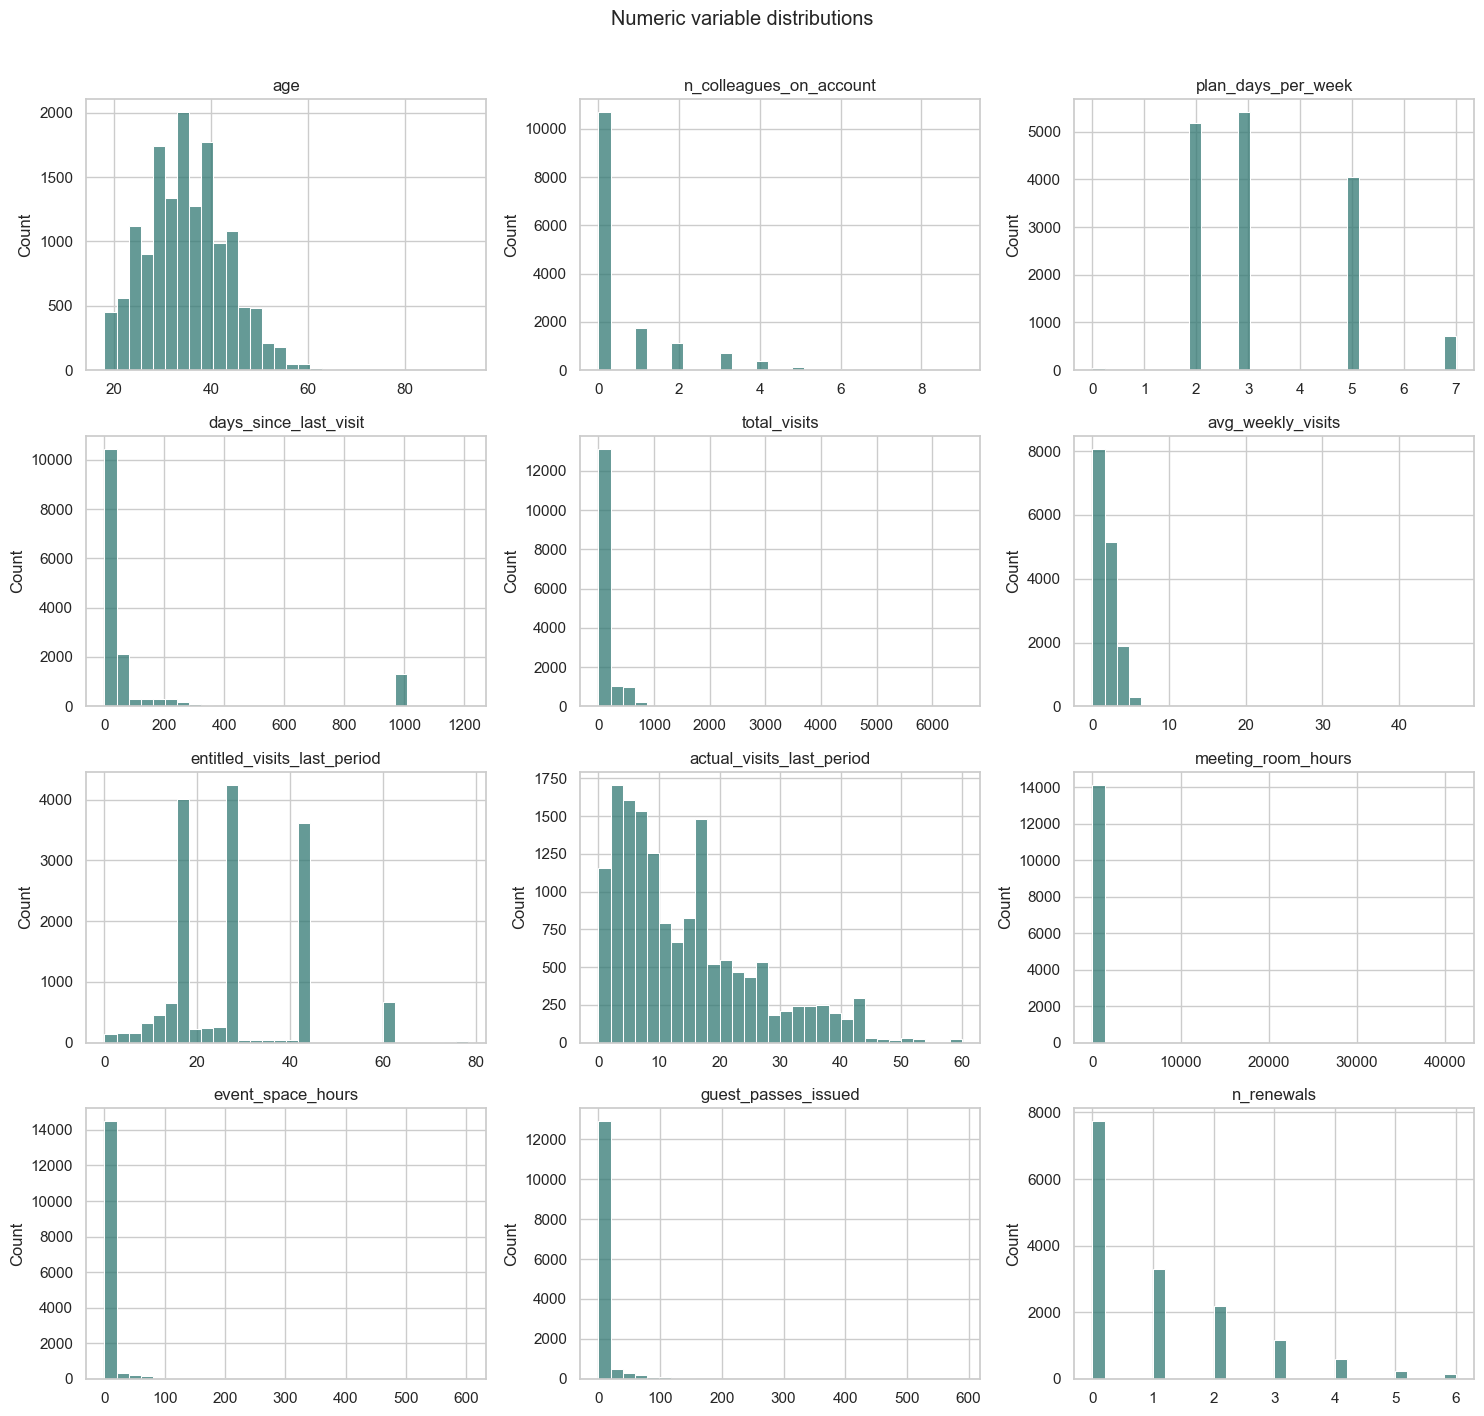

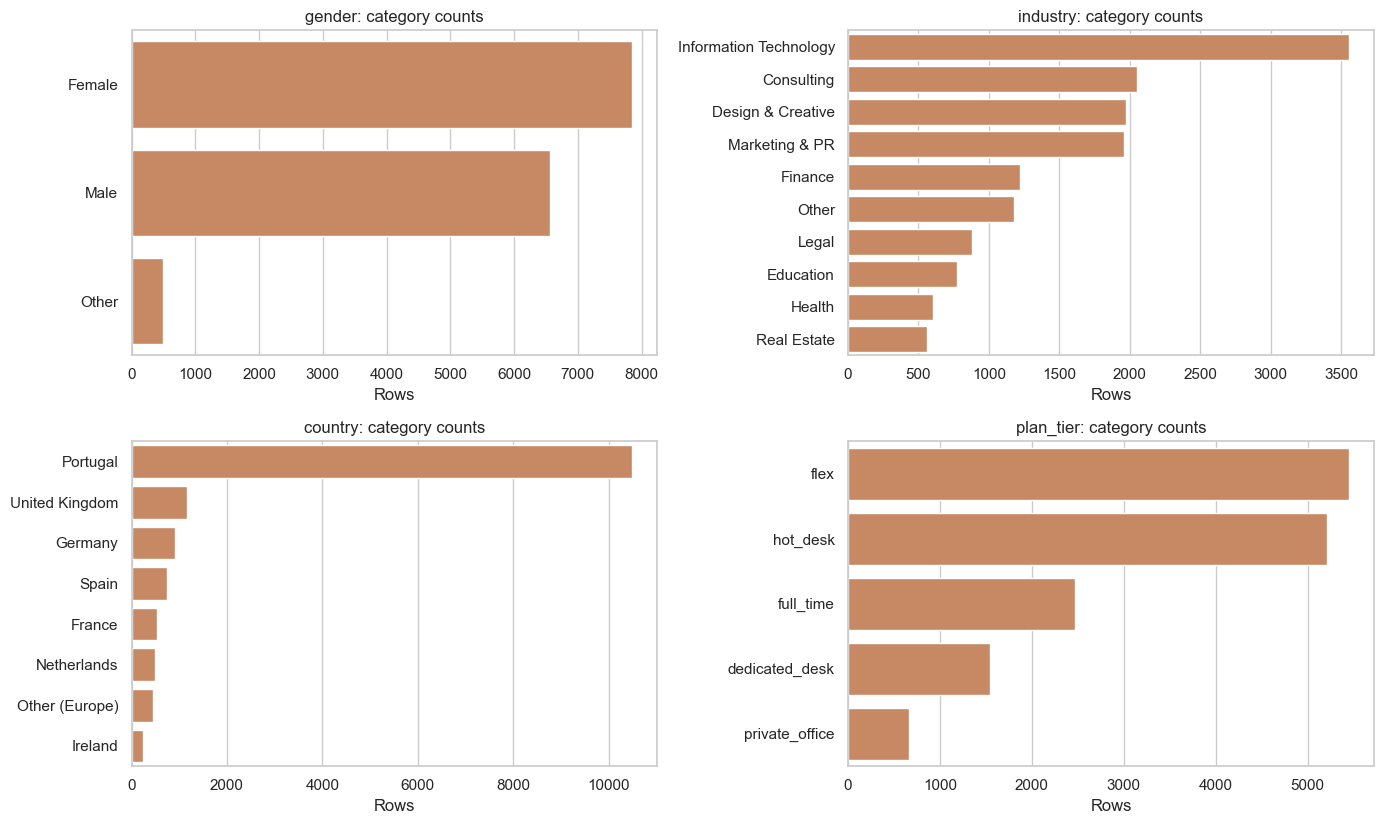

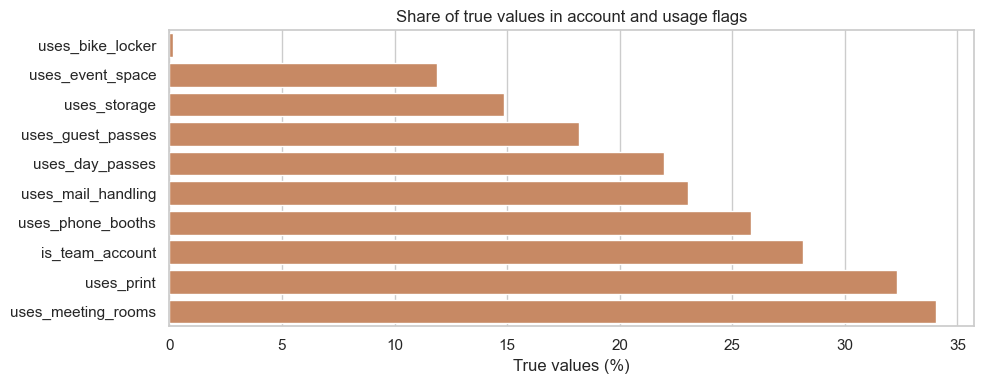

In [3]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if numeric_cols:
    ncols = 3
    nrows = int(np.ceil(len(numeric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, column in zip(axes, numeric_cols):
        sns.histplot(data=df, x=column, bins=30, ax=ax, color="#317873")
        ax.set_title(column)
        ax.set_xlabel("")
    for ax in axes[len(numeric_cols):]:
        ax.remove()
    fig.suptitle("Numeric variable distributions", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns available to plot.")

categorical_cols = [column for column in ["gender", "industry", "country", "plan_tier"] if column in df.columns]
if categorical_cols:
    ncols = 2
    nrows = int(np.ceil(len(categorical_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows))
    axes = np.asarray(axes).reshape(-1)
    for ax, column in zip(axes, categorical_cols):
        order = df[column].value_counts().index
        sns.countplot(data=df, y=column, order=order, ax=ax, color="#d78553")
        ax.set_title(f"{column}: category counts")
        ax.set_xlabel("Rows")
        ax.set_ylabel("")
    for ax in axes[len(categorical_cols):]:
        ax.remove()
    plt.tight_layout()
    plt.show()

boolean_cols = [column for column in ["is_team_account"] + [c for c in df.columns if c.startswith("uses_")] if column in df.columns]
boolean_map = {"true": 1, "false": 0, "yes": 1, "no": 0, "1": 1, "0": 0}
boolean_rates = pd.Series({
    column: df[column].astype("string").str.strip().str.lower().map(boolean_map).mean()
    for column in boolean_cols
}).dropna().sort_values()
if not boolean_rates.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(boolean_rates))))
    sns.barplot(x=boolean_rates.values * 100, y=boolean_rates.index, color="#d78553", ax=ax)
    ax.set(title="Share of true values in account and usage flags", xlabel="True values (%)", ylabel="")
    plt.tight_layout()
    plt.show()

## Date fields and possible sentinels

The date columns are parsed only for these plots; the stored DataFrame is left unchanged. The 1970 year is reported separately because the raw sample contains `1970-01-01`, which may be a sentinel rather than a real membership end date.

,n_unparseable,n_1970_sentinel,earliest_non_1970,latest
membership_start,637,0,2021-01-01,2023-12-30
membership_end,461,3954,2020-10-23,2024-01-01
last_badge_swipe,637,0,2020-09-06,2024-04-28


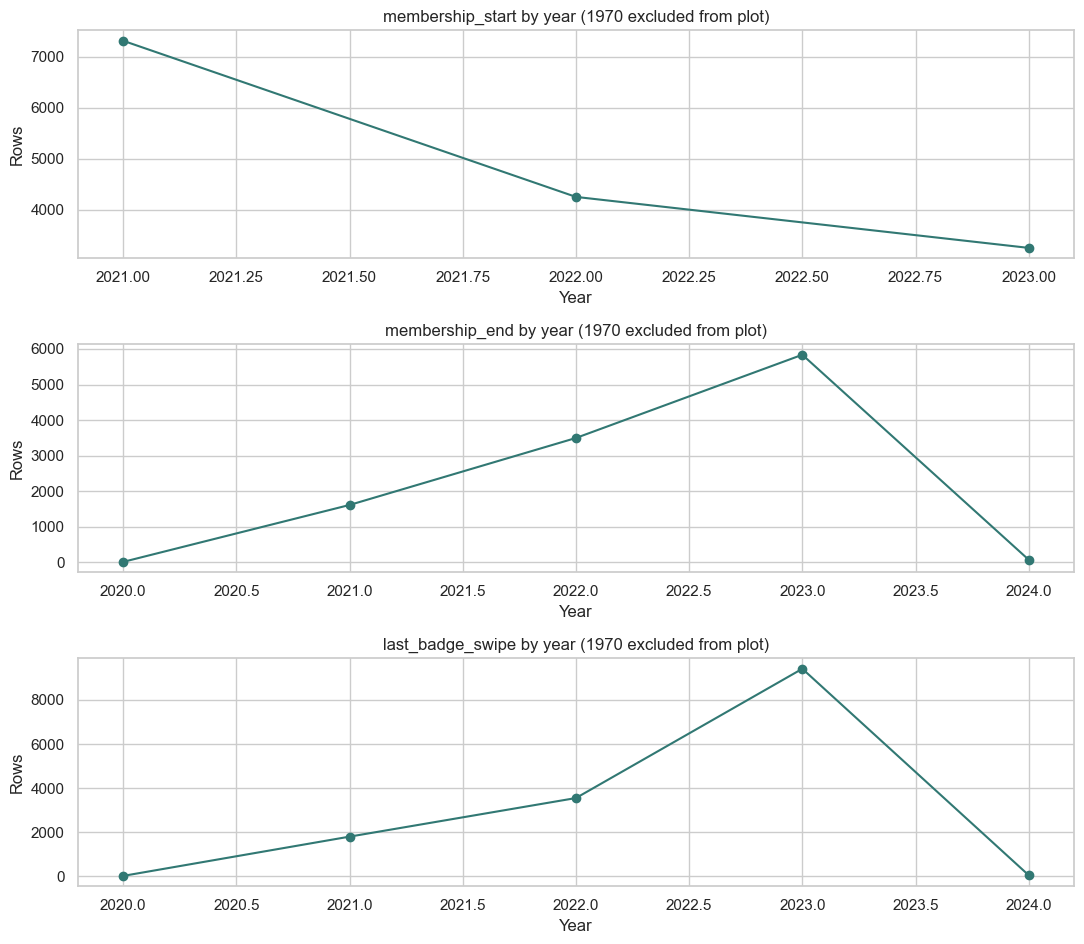

Found 144 end-before-start date pairs; dates are unchanged in the processed data.


,member_id,membership_start,membership_end,issue
0,CW000161,2021-10-25,2021-10-17,end_before_start
1,CW000284,2021-03-19,2021-03-12,end_before_start
2,CW000315,2021-08-17,2021-06-29,end_before_start
3,CW000498,2022-05-10,2022-02-10,end_before_start
4,CW000585,2022-09-20,2022-08-19,end_before_start
5,CW001018,2022-03-09,2021-12-17,end_before_start
6,CW001087,2021-06-26,2021-04-03,end_before_start
7,CW001125,2023-12-06,2023-10-01,end_before_start
8,CW001259,2022-03-10,2022-02-22,end_before_start
9,CW001281,2021-04-11,2021-03-24,end_before_start


In [5]:
date_cols = [column for column in ["membership_start", "membership_end", "last_badge_swipe"] if column in df.columns]
if date_cols:
    parsed_dates = pd.DataFrame({column: pd.to_datetime(df[column], errors="coerce") for column in date_cols})
    date_report = pd.DataFrame({
        "n_unparseable": {column: int((df[column].notna() & parsed_dates[column].isna()).sum()) for column in date_cols},
        "n_1970_sentinel": {column: int(parsed_dates[column].dt.year.eq(1970).sum()) for column in date_cols},
        "earliest_non_1970": {
            column: parsed_dates.loc[parsed_dates[column].dt.year.ne(1970), column].min()
            for column in date_cols
        },
        "latest": {column: parsed_dates[column].max() for column in date_cols},
    })
    display(date_report)

    fig, axes = plt.subplots(len(date_cols), 1, figsize=(11, 3.2 * len(date_cols)), squeeze=False)
    for ax, column in zip(axes[:, 0], date_cols):
        dates = parsed_dates[column]
        dates = dates.loc[dates.dt.year.ne(1970)].dropna()
        yearly_counts = dates.dt.year.value_counts().sort_index()
        if not yearly_counts.empty:
            ax.plot(yearly_counts.index, yearly_counts.values, marker="o", color="#317873")
        ax.set(title=f"{column} by year (1970 excluded from plot)", xlabel="Year", ylabel="Rows")
    plt.tight_layout()
    plt.show()
else:
    print("No expected date columns were found.")

# Review rows with end dates before start dates; source dates are preserved for investigation.
date_issue_path = PROJECT_ROOT / config["diagnostics"]["output_dir"] / "date_order_violations.csv"
if date_issue_path.is_file():
    date_order_issues = pd.read_csv(date_issue_path)
    print(f"Found {len(date_order_issues)} end-before-start date pairs; dates are unchanged in the processed data.")
    display(date_order_issues.head(20))
else:
    print("Date-order audit not found. Run `python main.py` first.")